In [13]:
# Import core manipulation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Spatial calculation helper (Haversine formula for globe distances)
from math import radians, cos, sin, asin, sqrt

print("Modeling environment initialized. Ready to build IDW framework!")

Modeling environment initialized. Ready to build IDW framework!


In [21]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    # Haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles
    
    return c * r

In [22]:
# 1. Target coordinate where your "Virtual Buoy" will live
VIRTUAL_LAT = 32.79481789562187
VIRTUAL_LON = -117.25924224137366

# 2. Coordinates of your 7 active operational physical nodes
# Formatted as: 'Station_ID': (Latitude, Longitude)
station_coordinates = {
    'ljac1': (32.867, -117.257),
    'ljpc1': (32.866, -117.255),
    '46254': (32.680, -117.350), 
    'sdbc1': (32.714, -117.174),
    '46266': (32.766, -117.369),  # New buoy added
    '46225': (32.503, -117.433),  # New buoy added
    '46258': (32.550, -117.420)
}

# 3. Compute and view the arc distances in kilometers
print("--- Great-Circle Distances to Virtual Point ---")
station_distances = {}
for station, coords in station_coordinates.items():
    dist = haversine_distance(VIRTUAL_LAT, VIRTUAL_LON, coords[0], coords[1])
    station_distances[station] = dist
    print(f"Node {station}: {dist:.2f} km away")

--- Great-Circle Distances to Virtual Point ---
Node ljac1: 8.03 km away
Node ljpc1: 7.93 km away
Node 46254: 15.33 km away
Node sdbc1: 12.01 km away
Node 46266: 10.75 km away
Node 46225: 36.30 km away
Node 46258: 31.10 km away


In [23]:
# directory path
data_dir = "../data"
successful_buoys = ['ljac1', 'ljpc1', '46254', 'sdbc1', '46266', '46225', '46258']
print("Synchronizing temporal metrics across spatial nodes...")

# master data frame holding time series + spatial data
combined_features = pd.DataFrame()

for station in successful_buoys:
    file_path = f"{data_dir}/{station}_cleaned.csv"
    
    if os.path.exists(file_path):
        # Read file, setting the time column as index
        df = pd.read_csv(file_path, index_col=0, parse_dates=True)
        
        # Rename columns uniquely so we know which metric belongs to which station
        # Example: WVHT becomes sdbc1_WVHT
        df = df.rename(columns={col: f"{station}_{col}" for col in df.columns})
        
        # Outer join combines data frames along identical timestamps, filling gaps with NaN
        if combined_features.empty:
            combined_features = df
        else:
            combined_features = combined_features.join(df, how='outer')
            
        print(f" Joined node {station} matrix layout.")

# Sort time index sequentially from oldest to newest
combined_features = combined_features.sort_index()

print(f"\n Master matrix built. Total synchronized timestamps: {len(combined_features)}")

Synchronizing temporal metrics across spatial nodes...
 Joined node ljac1 matrix layout.
 Joined node ljpc1 matrix layout.
 Joined node 46254 matrix layout.
 Joined node sdbc1 matrix layout.
 Joined node 46266 matrix layout.
 Joined node 46225 matrix layout.
 Joined node 46258 matrix layout.

 Master matrix built. Total synchronized timestamps: 9049


In [24]:
def predict_idw_parameter(timestamp_row, parameter_name, distances, power=2):
    """
    Computes the IDW interpolation for a target metric ('WVHT' or 'WSPD') 
    at a single timestamp row using active reporting buoys.
    """
    weighted_sum = 0.0
    total_weights = 0.0
    
    for station, distance in distances.items():
        col_name = f"{station}_{parameter_name}"
        
        # Check if the station has a valid reading at this specific snapshot in time
        if col_name in timestamp_row and not np.isnan(timestamp_row[col_name]):
            # Avoid division by zero if a buoy sits exactly on the virtual point
            if distance == 0:
                return timestamp_row[col_name]
                
            # Compute IDW Weight: w = 1 / (d^p)
            weight = 1.0 / (distance ** power)
            
            weighted_sum += weight * timestamp_row[col_name]
            total_weights += weight
            
    # Fallback to NaN if no neighboring stations logged data for this timestamp
    if total_weights == 0:
        return np.nan
        
    return weighted_sum / total_weights

In [28]:
# Arrays to store our generated virtual timelines, now fully fleshed out!
virtual_wvht = []
virtual_wspd = []
virtual_dpd = []
virtual_apd = []
virtual_wtmp = []  # Added tracking array

print("Running IDW model vector space loop across time arrays...")

for index, row in combined_features.iterrows():
    virtual_wvht.append(predict_idw_parameter(row, 'WVHT', station_distances))
    virtual_wspd.append(predict_idw_parameter(row, 'WSPD', station_distances))
    virtual_dpd.append(predict_idw_parameter(row, 'DPD', station_distances))
    virtual_apd.append(predict_idw_parameter(row, 'APD', station_distances))
    virtual_wtmp.append(predict_idw_parameter(row, 'WTMP', station_distances)) # Added WTMP IDW call

# Construct your ultimate synthetic DataFrame for PB Pier South
virtual_buoy_df = pd.DataFrame({
    'Virtual_WVHT_m': virtual_wvht,
    'Virtual_WSPD_ms': virtual_wspd,
    'Virtual_DPD_s': virtual_dpd,
    'Virtual_APD_s': virtual_apd,
    'Virtual_WTMP_C': virtual_wtmp  # Saved in Celsius as standardized by NOAA
}, index=combined_features.index).dropna(how='all')

print(f"Framework updated! Final Shape: {virtual_buoy_df.shape}")
# virtual_buoy_df.head()

Running IDW model vector space loop across time arrays...
Framework updated! Final Shape: (9049, 5)


In [26]:
virtual_buoy_df

,Virtual_WVHT_m,Virtual_WSPD_ms,Virtual_DPD_s,Virtual_APD_s,Virtual_WTMP_C
timestamp,,,,,
2026-06-20 10:12:00,NaN,1.0,NaN,NaN,19.100000
2026-06-20 10:18:00,NaN,1.0,NaN,NaN,19.100000
2026-06-20 10:20:00,0.700000,1.0,5.000000,5.000000,NaN
2026-06-20 10:24:00,NaN,1.0,NaN,NaN,19.061758
2026-06-20 10:26:00,0.991275,NaN,13.283440,7.047963,19.441193
...,...,...,...,...,...
2026-07-20 09:48:00,NaN,0.5,NaN,NaN,22.908791
2026-07-20 09:54:00,NaN,1.0,NaN,NaN,22.839670
2026-07-20 09:56:00,0.834276,NaN,11.746398,5.959109,23.761786


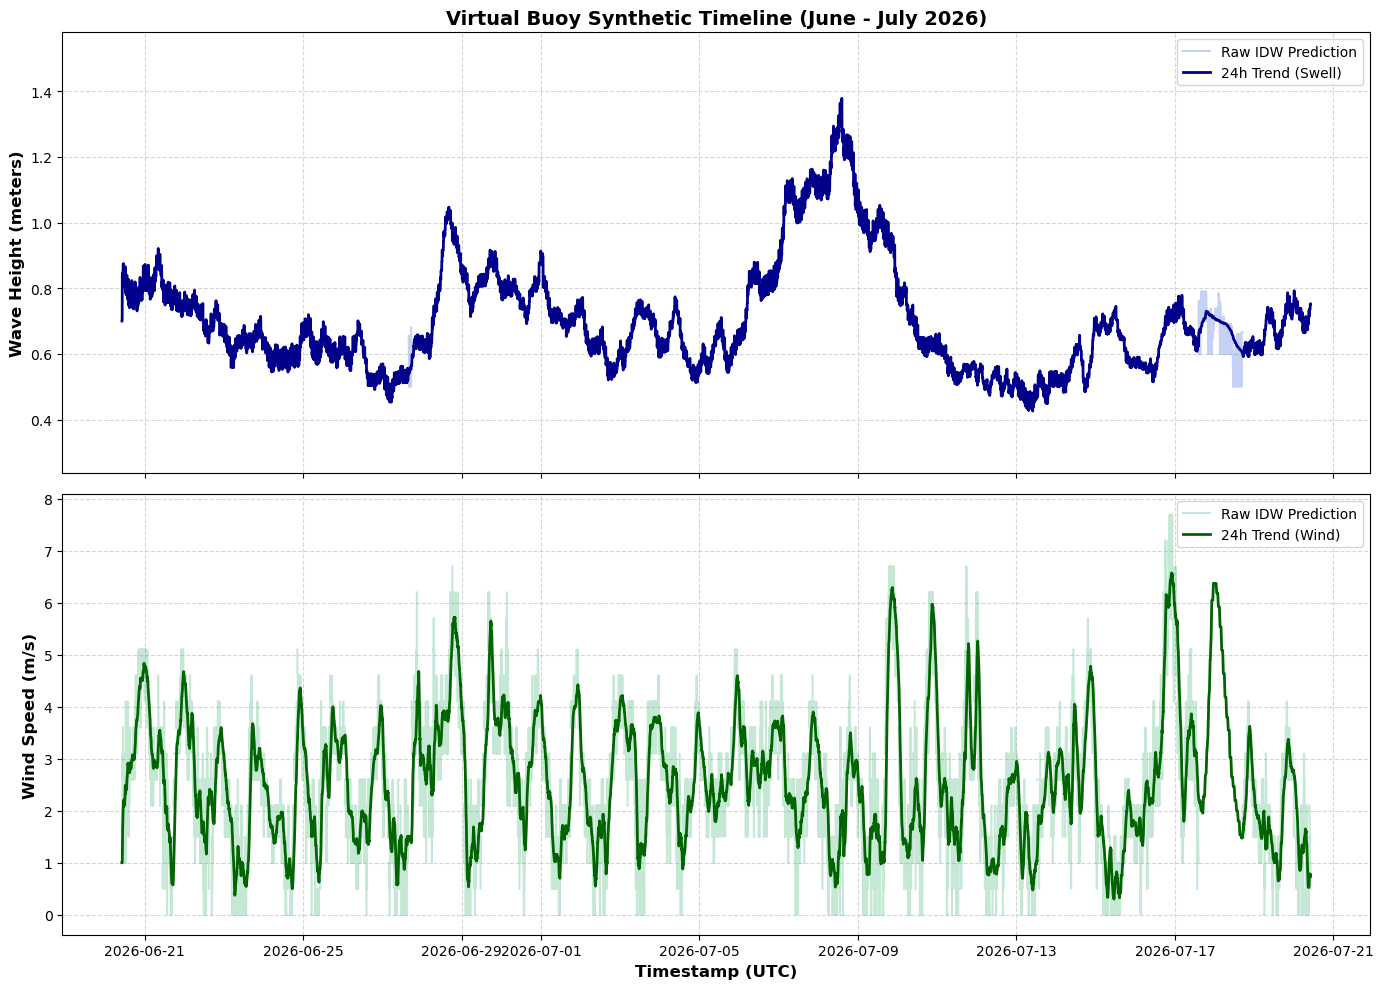

In [27]:
# Create a figure with two subplots: one for Wave Height, one for Wind Speed
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Subplot 1: Wave Height ---
# Plot raw predictions as a light scatter/line to see the raw variance
ax1.plot(virtual_buoy_df.index, virtual_buoy_df['Virtual_WVHT_m'], 
         alpha=0.3, color='royalblue', label='Raw IDW Prediction')

# Plot a 24-hour rolling average (assuming ~6-10 min intervals, adjust window as needed)
# This helps visually track major swell events
rolling_wvht = virtual_buoy_df['Virtual_WVHT_m'].rolling(window=24, min_periods=1).mean()
ax1.plot(virtual_buoy_df.index, rolling_wvht, 
         color='darkblue', linewidth=2, label='24h Trend (Swell)')

ax1.set_ylabel('Wave Height (meters)', fontsize=12, fontweight='bold')
ax1.set_title('Virtual Buoy Synthetic Timeline (June - July 2026)', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')

# --- Subplot 2: Wind Speed ---
ax2.plot(virtual_buoy_df.index, virtual_buoy_df['Virtual_WSPD_ms'], 
         alpha=0.3, color='mediumseagreen', label='Raw IDW Prediction')

rolling_wspd = virtual_buoy_df['Virtual_WSPD_ms'].rolling(window=24, min_periods=1).mean()
ax2.plot(virtual_buoy_df.index, rolling_wspd, 
         color='darkgreen', linewidth=2, label='24h Trend (Wind)')

ax2.set_ylabel('Wind Speed (m/s)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Timestamp (UTC)', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')

# Optimize layout to prevent text clipping
plt.tight_layout()
plt.show()